<a href="https://colab.research.google.com/github/sjakku-ai/DigitalTransformation/blob/main/Classification_Term2_March2026-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Approach:
1. Load the data
2. Data Exploration
3. Data Preparation
4. Apply ML Model
5. Evaluate the ML Model
6. Create simple application

In [ ]:
import requests
import zipfile
import io
import pandas as pd
import os

zip_url = 'https://gitlab.com/accredian/insaid-data/-/raw/main/Terms%202025/archive__2___1_.zip'
output_zip_filename = 'downloaded_archive.zip'
extract_dir = 'extracted_data'

print(f"Downloading ZIP file from: {zip_url}")
try:
    response = requests.get(zip_url, stream=True)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    with open(output_zip_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"'{output_zip_filename}' downloaded successfully.")

    # Create a directory to extract files into
    os.makedirs(extract_dir, exist_ok=True)

    # Extract the ZIP file
    with zipfile.ZipFile(output_zip_filename, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Contents extracted to '{extract_dir}/'.")

    # List contents of the extracted directory
    extracted_files = os.listdir(extract_dir)
    print(f"Extracted files: {extracted_files}")

    # Try to find and load a CSV file (assuming the primary data is CSV)
    csv_files = [f for f in extracted_files if f.lower().endswith('.csv')]
    if csv_files:
        data_file_path = os.path.join(extract_dir, csv_files[0])
        print(f"Attempting to load '{data_file_path}' into a DataFrame...")
        df = pd.read_csv(data_file_path)
        print("Data loaded successfully. Displaying first 5 rows:")
        display(df.head())
    else:
        print("No CSV files found in the extracted archive. Please specify which file to load or adjust the loading logic if it's another format.")

except requests.exceptions.RequestException as e:
    print(f"Error downloading file: {e}")
except zipfile.BadZipFile:
    print("Error: The downloaded file is not a valid ZIP archive.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


'downloaded_archive.zip' downloaded successfully.
Contents extracted to 'extracted_data/'.
Extracted files: ['Bank Customer Churn Prediction.csv']
Attempting to load 'extracted_data/Bank Customer Churn Prediction.csv' into a DataFrame...
Data loaded successfully. Displaying first 5 rows:


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


--- 1. Basic Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB

--- 2. Missing Values ---
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenu

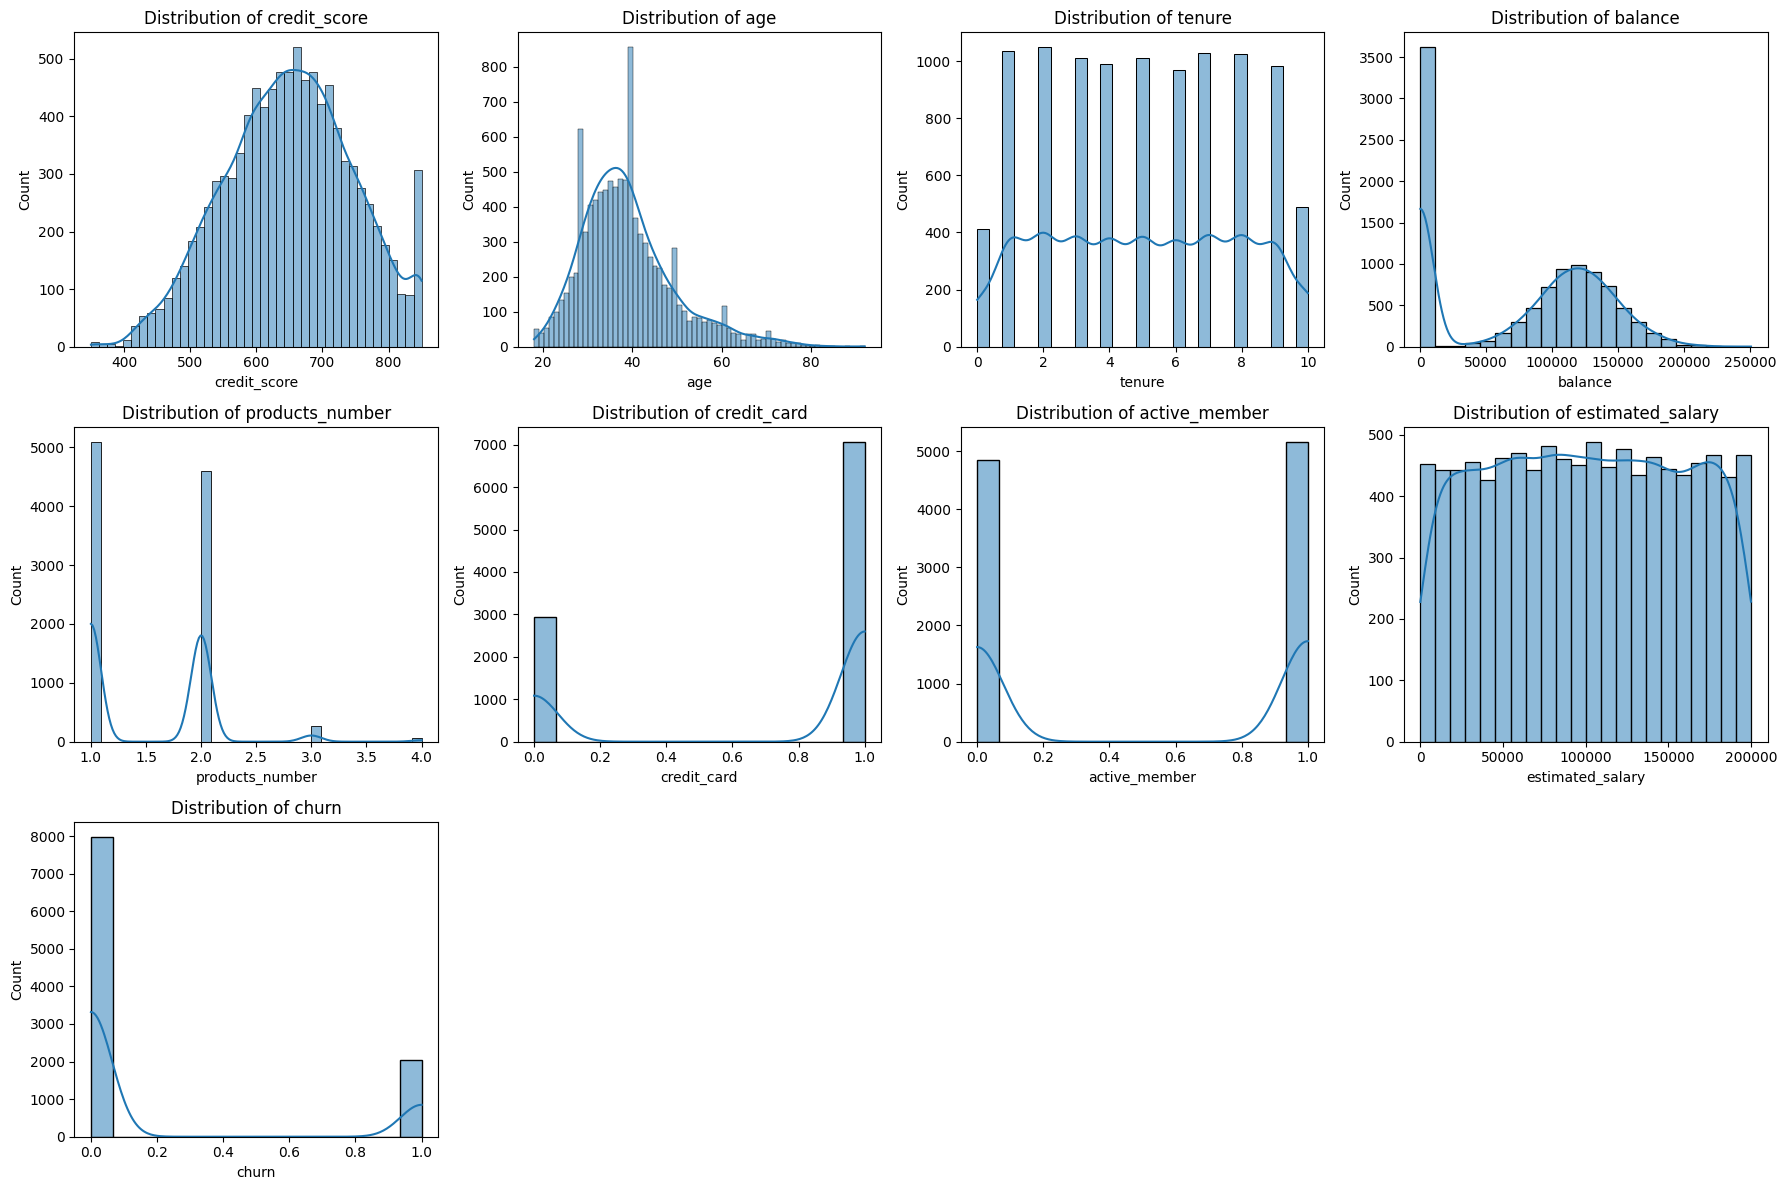


Generating Count Plots for Categorical Features...


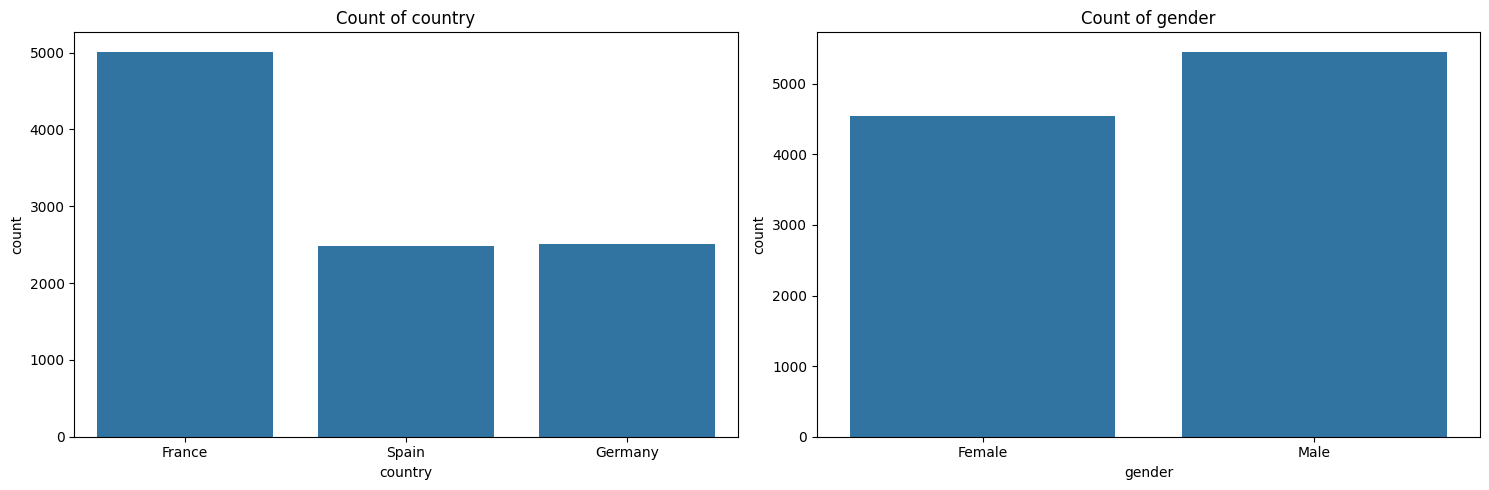


--- 6. Correlation Matrix of Numerical Features ---


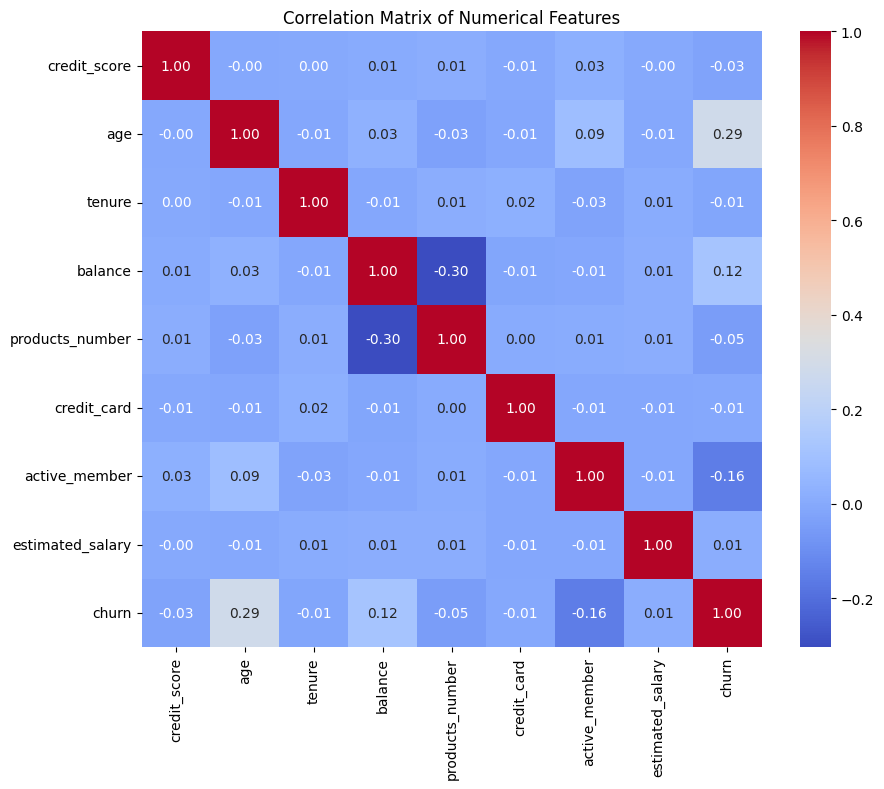


--- 7. Target Variable Analysis: Churn ---
Churn Value Counts:
churn
0    7963
1    2037
Name: count, dtype: int64

Churn Proportion:
churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64

Churn Distribution by Categorical Features...


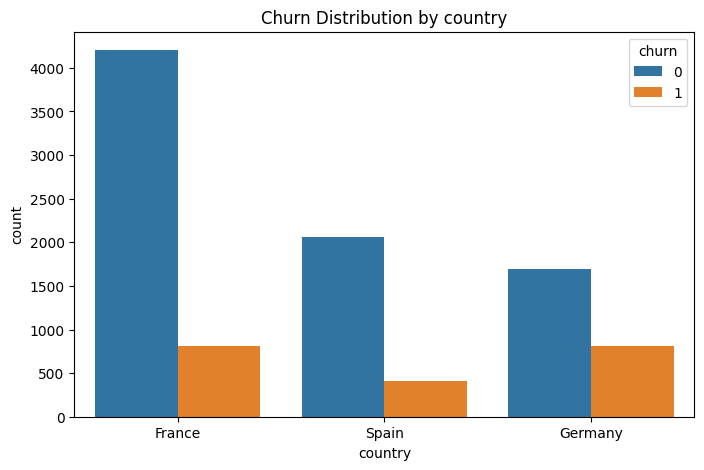

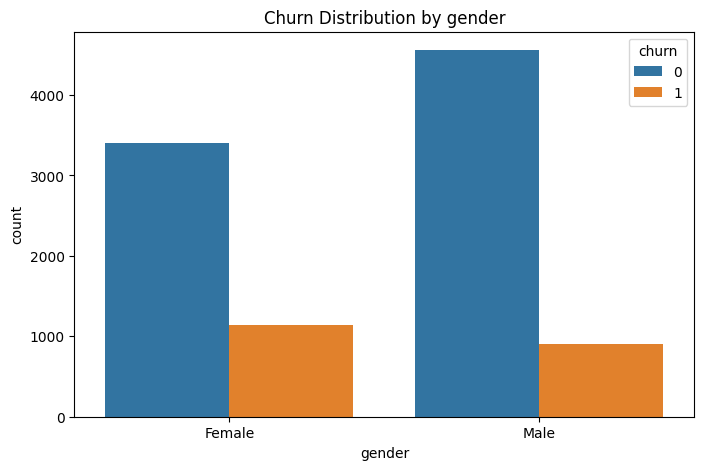


Churn Distribution by Numerical Features (Box Plots)...


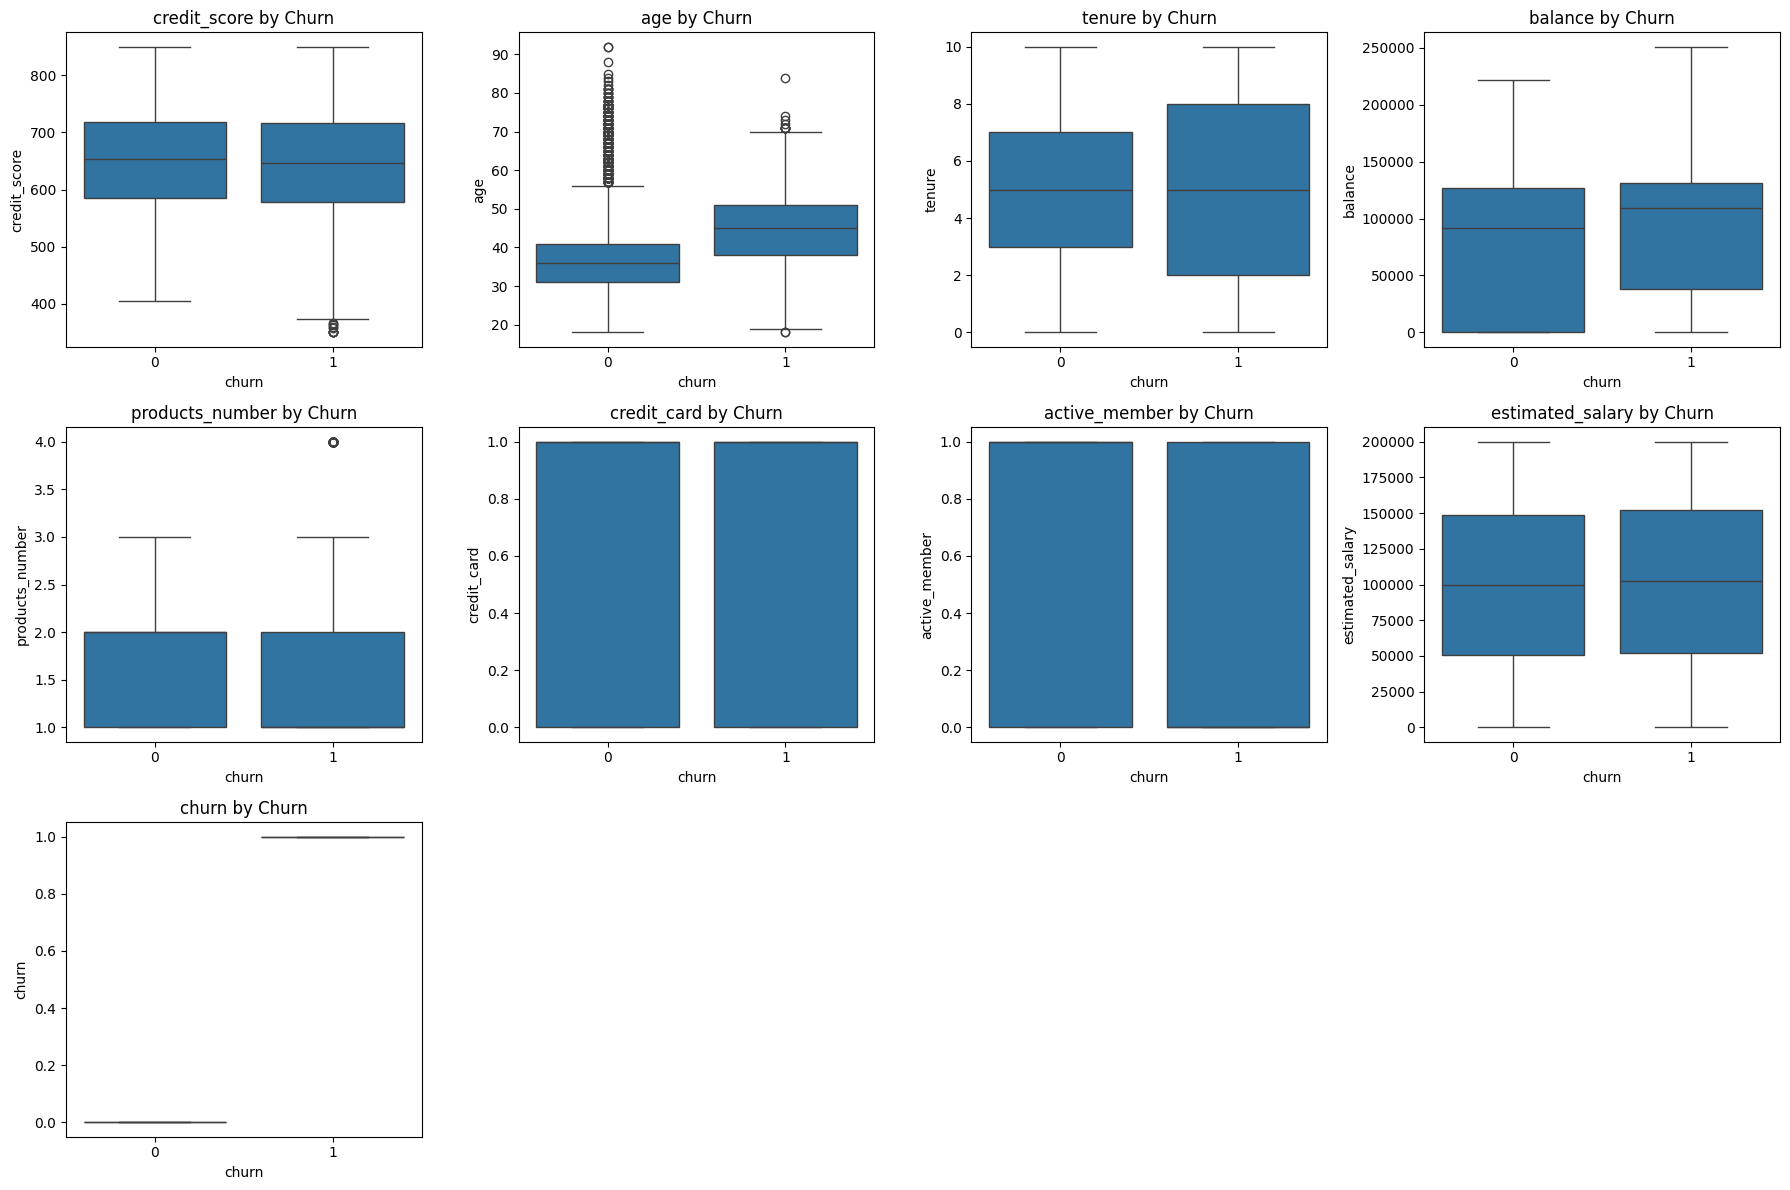


EDA complete. Please review the output and visualizations for detailed insights.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Basic Information and Missing Values ---
print("--- 1. Basic Information ---")
df.info()
print("\n--- 2. Missing Values ---")
print(df.isnull().sum())

# --- 3. Descriptive Statistics ---
print("\n--- 3. Descriptive Statistics for Numerical Columns ---")
print(df.describe())

print("\n--- 4. Descriptive Statistics for Categorical Columns ---")
print(df.describe(include='object'))

# --- 5. Data Distribution Analysis (Visualizations) ---
print("\n--- 5. Data Distribution Analysis (Visualizations) ---")

# Separate features by type
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include='object').columns

# Exclude 'customer_id' as it's an identifier and not a feature for distribution analysis
if 'customer_id' in numerical_cols:
    numerical_cols = numerical_cols.drop('customer_id')

# Histograms for numerical features
print("\nGenerating Histograms for Numerical Features...")
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Count plots for categorical features
print("\nGenerating Count Plots for Categorical Features...")
if len(categorical_cols) > 0:
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(categorical_cols):
        plt.subplot(1, len(categorical_cols), i + 1)
        sns.countplot(x=col, data=df)
        plt.title(f'Count of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found for count plots.")

# --- 6. Correlation Analysis ---
print("\n--- 6. Correlation Matrix of Numerical Features ---")
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# --- 7. Target Variable Analysis (Churn) ---
print("\n--- 7. Target Variable Analysis: Churn ---")
if 'churn' in df.columns:
    print("Churn Value Counts:")
    print(df['churn'].value_counts())
    print("\nChurn Proportion:")
    print(df['churn'].value_counts(normalize=True))

    # Churn by categorical features
    print("\nChurn Distribution by Categorical Features...")
    for col in categorical_cols:
        plt.figure(figsize=(8, 5))
        sns.countplot(x=col, hue='churn', data=df)
        plt.title(f'Churn Distribution by {col}')
        plt.show()

    # Churn by numerical features (e.g., box plots)
    print("\nChurn Distribution by Numerical Features (Box Plots)...")
    plt.figure(figsize=(18, 12))
    for i, col in enumerate(numerical_cols):
        plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
        sns.boxplot(x='churn', y=col, data=df)
        plt.title(f'{col} by Churn')
    plt.tight_layout()
    plt.show()
else:
    print("Target variable 'churn' not found in DataFrame.")

print("\nEDA complete. Please review the output and visualizations for detailed insights.")


In [ ]:
pip install autosklearn

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Assuming 'df' is your DataFrame and 'churn' is the target variable

# 1. Separate target variable
X = df.drop('churn', axis=1)
y = df['churn']

# 2. Drop 'customer_id' as it's an identifier and not a feature
if 'customer_id' in X.columns:
    X = X.drop('customer_id', axis=1)

# 3. Identify categorical and numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print(f"Numerical columns: {list(numerical_cols)}")
print(f"Categorical columns: {list(categorical_cols)}")

# 4. Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore') # handle_unknown='ignore' to prevent errors for new categories in test set

# 5. Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# 6. Apply preprocessing to the features
# We'll apply this within a pipeline later, or directly if just preparing X

# 7. Split the data into training and testing sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Now, apply the preprocessing to the training and testing sets separately to avoid data leakage
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("\nData preparation complete:")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("Features X_train, X_test and target y_train, y_test are now ready for ML model training.")


Numerical columns: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
Categorical columns: ['country', 'gender']

Data preparation complete:
Shape of X_train: (8000, 13)
Shape of X_test: (2000, 13)
Shape of y_train: (8000,)
Shape of y_test: (2000,)
Features X_train, X_test and target y_train, y_test are now ready for ML model training.


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

# Install autosklearn if not already installed
try:
    import autosklearn.classification
    print("autosklearn found.")
except ImportError:
    print("autosklearn not found. Installing 'auto-sklearn'...")
    # Correct installation command for auto-sklearn
    !pip install auto-sklearn
    # Attempt to import again after installation
    try:
        import autosklearn.classification
        print("autosklearn installed and imported successfully.")
    except ImportError as e:
        print("Installation successful, but `autosklearn` could not be imported immediately. Please restart the runtime (Runtime -> Restart runtime) and re-run this cell.")
        raise # Re-raise to make the error visible and prompt user action

print("Applying AutoML with AutoSklearn...")

# Initialize AutoSklearn Classifier
# time_left_for_this_task: total time in seconds for the AutoML run
# per_run_time_limit: time in seconds for each model configuration
# n_jobs: number of parallel jobs (set to -1 to use all available cores)
automl = autosklearn.classification.AutoSklearnClassifier(
    time_left_for_this_task=360, # 6 minutes for demonstration. Can be increased for better results.
    per_run_time_limit=60,      # 1 minute per model configuration
    n_jobs=-1,                  # Use all available cores
    resampling_strategy='holdout',
    resampling_strategy_arguments={'train_size': 0.8},
    ensemble_size=5,             # Number of models in the ensemble
    seed=42
)

# Fit the AutoML model to the training data
automl.fit(X_train, y_train)

print("AutoML training complete.")

# Print the best model's information
print("\nBest model ensemble information:")
print(automl.show_models())

# Make predictions on the test set
y_pred = automl.predict(X_test)

# Evaluate the best model
print("\nModel Evaluation on Test Set:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

# For ROC AUC, we need probabilities. If supported by the ensemble:
try:
    y_proba = automl.predict_proba(X_test)[:, 1]
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
except Exception as e:
    print(f"Could not compute ROC AUC score: {e}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nSummary of the best performing models found by AutoSklearn:")
print(automl.leaderboard())

ModuleNotFoundError: No module named 'autosklearn'

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

print("Applying XGBoost Classifier with Hyperparameter Tuning...")

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress the warning
    random_state=42
)

# Define the hyperparameter grid to search
# This is an example grid, you might want to expand or adjust it
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Set up GridSearchCV
# verbose=2 to see progress, cv=3 or 5 for cross-validation folds
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=2,
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

print("GridSearchCV complete.")

# Get the best estimator
best_xgb_model = grid_search.best_estimator_

print("\nBest Hyperparameters found:")
print(grid_search.best_params_)

# Make predictions on the test set using the best model
y_pred_xgb = best_xgb_model.predict(X_test)
y_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the best XGBoost model
print("\nModel Evaluation on Test Set (XGBoost):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

print("\nConfusion Matrix (XGBoost):")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

print("XGBoost model training and evaluation complete.")

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

# Ensure the preprocessor and best_xgb_model are available from previous cells
# (Assuming cells 1OWG2i0ub93I and tN3iye2SI22M have been executed successfully)

# Define the prediction function
def predict_churn(
    credit_score,
    country,
    gender,
    age,
    tenure,
    balance,
    products_number,
    credit_card,
    active_member,
    estimated_salary
):
    # Create a DataFrame from the inputs, ensuring correct column order and names
    input_data = pd.DataFrame([[
        credit_score,
        country,
        gender,
        age,
        tenure,
        balance,
        products_number,
        credit_card,
        active_member,
        estimated_salary
    ]], columns=[
        'credit_score',
        'country',
        'gender',
        'age',
        'tenure',
        'balance',
        'products_number',
        'credit_card',
        'active_member',
        'estimated_salary'
    ])

    # Preprocess the input data using the trained preprocessor
    # Note: preprocessor.transform expects 2D array, so input_data is suitable
    # This assumes 'preprocessor' is globally available from the data preparation step
    try:
        processed_input = preprocessor.transform(input_data)
    except Exception as e:
        return f"Error during preprocessing: {e}. Please ensure all input fields are valid."

    # Make prediction using the best XGBoost model
    # This assumes 'best_xgb_model' is globally available from the XGBoost training step
    prediction_proba = best_xgb_model.predict_proba(processed_input)[0]
    churn_proba = prediction_proba[1] # Probability of churn (class 1)

    # Determine the result based on a threshold (e.g., 0.5)
    if churn_proba >= 0.5:
        result = f"Likely to CHURN (Probability: {churn_proba:.2f})"
    else:
        result = f"Unlikely to CHURN (Probability: {churn_proba:.2f})"

    return result

# Define Gradio interface components based on the features
# Min/Max values are inferred from the EDA (cell _gnOyBeXRbp6)
inputs = [
    gr.Slider(minimum=350, maximum=850, step=1, default=650, label="Credit Score"),
    gr.Dropdown(['France', 'Germany', 'Spain'], label="Country", value='France'),
    gr.Radio(['Male', 'Female'], label="Gender", value='Male'),
    gr.Slider(minimum=18, maximum=92, step=1, default=38, label="Age"),
    gr.Slider(minimum=0, maximum=10, step=1, default=5, label="Tenure (Years)"),
    gr.Number(value=75000.00, label="Balance"),
    gr.Slider(minimum=1, maximum=4, step=1, default=1, label="Number of Products"),
    gr.Radio([0, 1], label="Has Credit Card (0=No, 1=Yes)", value=1),
    gr.Radio([0, 1], label="Is Active Member (0=No, 1=Yes)", value=1),
    gr.Number(value=100000.00, label="Estimated Salary")
]

output = gr.Textbox(label="Churn Prediction")

# Create and launch the Gradio interface
iface = gr.Interface(
    fn=predict_churn,
    inputs=inputs,
    outputs=output,
    title="Customer Churn Prediction",
    description="Enter customer details to predict if they will churn."
)

print("Launching Gradio app...")
iface.launch(share=True, debug=True)
